In [6]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

# import pandas as pd
# import matplotlib.pyplot as plt
# import reciprocalspaceship as rs
# from occupancy import *
# from plotting3d import *
%load_ext autoreload 
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import reciprocalspaceship as rs
import pandas as pd
from meteor import rsmap
from meteor.utils import cut_resolution

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
# from meteor.tv import tv_denoise_difference_map
# from meteor.validate import map_negentropy

In [8]:
def get_scaling_factors(diffmaps, rescale_key, diffmap_id, shares, map_sampling=3):
    ref_map = diffmaps[rescale_key].to_3d_numpy_map(map_sampling=map_sampling)
    scale_map = diffmaps[diffmap_id].to_3d_numpy_map(map_sampling=map_sampling)
    neg_scales = []
    pos_scales = []
    for share in shares:
        k = int(share * ref_map.size)
        # Get k largest values
        largest_indices = np.argpartition(ref_map.flatten(), -k)[-k:]
        largest_values_ref = ref_map.flatten()[largest_indices]
        largest_indices = np.argpartition(scale_map.flatten(), -k)[-k:]
        largest_values_scale = scale_map.flatten()[largest_indices]

        # Get k smallest values
        smallest_indices = np.argpartition(ref_map.flatten(), k)[:k]
        smallest_values_ref = ref_map.flatten()[smallest_indices]
        smallest_indices = np.argpartition(scale_map.flatten(), k)[:k]
        smallest_values_scale = scale_map.flatten()[smallest_indices]
        # Compute scaling factors using percentiles
        pos_scale = np.mean(largest_values_ref) / np.mean(largest_values_scale)
        neg_scale = np.min(smallest_values_ref) / np.min(smallest_values_scale)
        neg_scales.append(neg_scale)
        pos_scales.append(pos_scale)
    return neg_scales, pos_scales


In [13]:
%matplotlib inline
from systematic_plots import (
    load_inputs,
    load_homepath,
    calculate_objects,
    rescaling_diffmaps,
)
filename_dict = {
    "save_fig": True,
    "display": False,
    "rerun": True,
    "rerun_old_only": False,
    "rescaling_diffmaps": True,
}
diffmap_ids = ["kweighted"]
diffmap_ids = ["kweighted", "tv"]
rescale_key = "vanilla_diffmap"
function_selection = [
    # "single_negsum_overview",
    "many_negsum_best_guess",
    # "many_negsum_many_thresh",
    # "show_comparison",
]

from systematic_plots import load_ocp_paths
info_containers = load_inputs()
info_containers = load_ocp_paths()
evaluation_path = load_homepath() + "../evaluation/"
print(evaluation_path)
if not os.path.exists(evaluation_path):
    os.makedirs(evaluation_path)
outputs = []
count = 0
for info_container in info_containers:
    count += 1
    if count>4:
        break
    # logger.info(f"\n\nrunning {info_container['tname']}\n\n")

    diffmaps, map_dark, info_container, evaluation_path_basis = calculate_objects(
        info_container, evaluation_path
    )
    info_container = info_container 

    del diffmaps["direct_realspace"]
    # reduce diffmaps to kweigthed and tv:
    # diffmaps = {diffmap_id: diffmaps[diffmap_id] for diffmap_id in diffmap_ids}

    shares = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]
    map_sampling = info_container["map_sampling"]
    break


2025-08-30 14:17:52,408: systematic_plots: INFO: Loading Photolyase paths (systematic_plots.py:1232)
2025-08-30 14:17:52,409: systematic_plots: INFO: Loaded Photolyase 100us with photolyase_100us (systematic_plots.py:1277)
2025-08-30 14:17:52,409: systematic_plots: INFO: Loaded Photolyase 10us with photolyase_10us (systematic_plots.py:1277)
2025-08-30 14:17:52,409: systematic_plots: INFO: Loaded Photolyase 30ns with photolyase_30ns (systematic_plots.py:1277)
2025-08-30 14:17:52,409: systematic_plots: INFO: Loaded Photolyase 300ps with photolyase_300ps (systematic_plots.py:1277)
2025-08-30 14:17:52,410: systematic_plots: INFO: Loaded Photolyase 30us with photolyase_30us (systematic_plots.py:1277)
2025-08-30 14:17:52,410: systematic_plots: INFO: Loaded Photolyase 3ps with photolyase_3ps (systematic_plots.py:1277)
2025-08-30 14:17:52,410: systematic_plots: INFO: Loaded Photolyase 1ns with photolyase_1ns (systematic_plots.py:1277)
2025-08-30 14:17:52,410: systematic_plots: INFO: Loaded Pho

/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../evaluation/


2025-08-30 14:17:52,866: systematic_plots: INFO: Reading from /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../evaluation/OCP/diffmaps17.mtz (systematic_plots.py:1755)


KeyError: 'direct_realspace'

In [14]:
info_container["fshort"]

'OCP'

2025-08-30 14:17:57,672: meteorize: INFO: Rescaled map by factor 3.826207399368286 (meteorize.py:808)


57.78298
63.126892


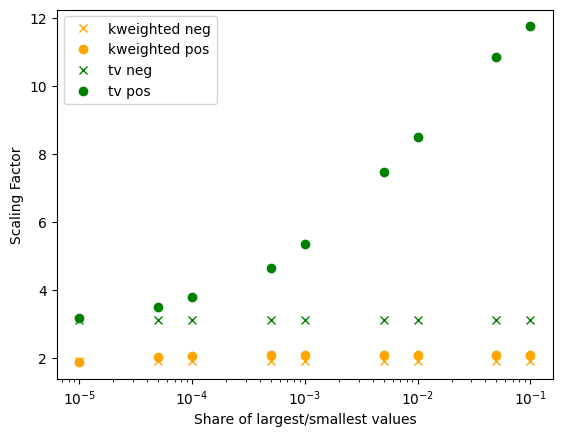

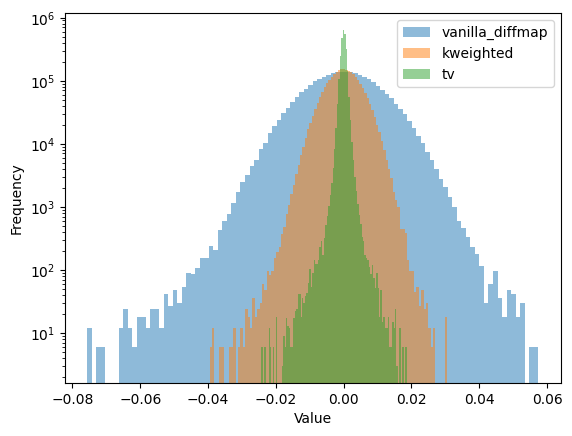

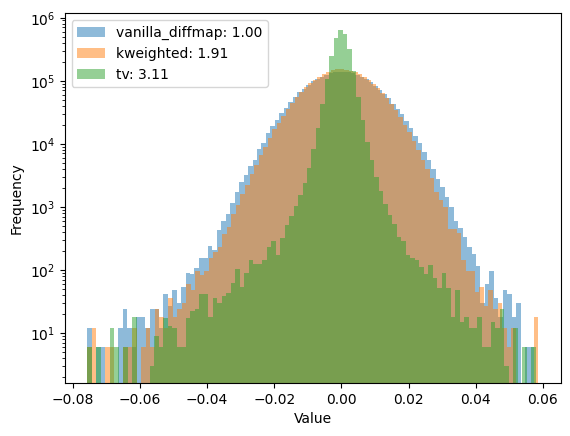

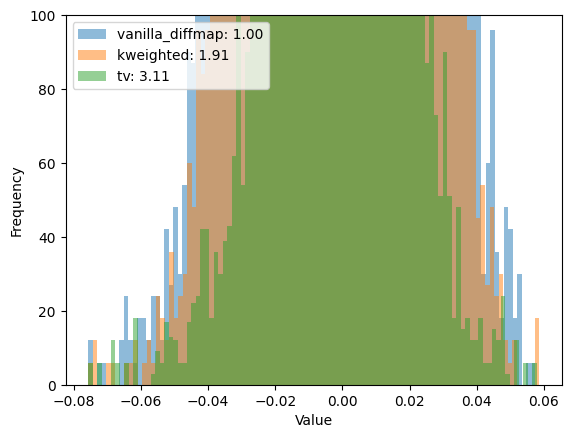

In [15]:
from systematic_plots import rescaling_diffmap, adding_maps
def new_diffmap(diffmap, reference_diffmap, map_dark, xtr_factor):
    diffmap =rescaling_diffmap(diffmap.copy(), reference_diffmap) 
    xtr_map = adding_maps(map_dark, diffmap, factor2=xtr_factor)
    new_diffmap = adding_maps(map_dark, xtr_map, factor1=-1)
    print(np.mean(new_diffmap.amplitudes - diffmap.amplitudes))
    print(np.mean(new_diffmap.amplitudes - reference_diffmap.amplitudes))
    new_diffmap.amplitudes = (reference_diffmap.amplitudes)
    return new_diffmap

xtr_factor = 6.3
diffmap = new_diffmap(diffmaps["kweighted"], diffmaps["vanilla_diffmap"], map_dark, xtr_factor)
diffmaps["marius"] = diffmap
shares = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]
map_sampling = info_container["map_sampling"]
del diffmaps["marius"]

scale_factors = {}
colors = ["orange", "green", "red", "blue", ]
plt.figure()
for key, diffmap in diffmaps.items():

    if key == rescale_key:
        continue
    neg_scales, pos_scales = get_scaling_factors(
        diffmaps, rescale_key, key, shares, map_sampling=map_sampling
    )
    color = colors.pop(0)
    plt.plot(shares, neg_scales, label=key + " neg", linestyle="", marker="x", color=color)
    plt.plot(shares, pos_scales, label=key + " pos", linestyle="", marker = "o", color=color)
    scale_factors[ key + "_neg"] = neg_scales
    scale_factors[ key + "_pos"] = pos_scales
plt.legend()
plt.xlabel("Share of largest/smallest values")
plt.ylabel("Scaling Factor")
plt.xscale("log")
plt.show()

plt.figure()
for key, diffmap in diffmaps.items():
    scale_map = diffmap.to_3d_numpy_map(map_sampling=map_sampling)
    scale_by = 1
    plt.hist(scale_map.flatten()*scale_by, bins=100, label=key, alpha=0.5)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.yscale("log")
plt.show()
plt.figure()
for key, diffmap in diffmaps.items():
    scale_map = diffmap.to_3d_numpy_map(map_sampling=map_sampling)
    if key == rescale_key:
        scale_by = 1
    else:
        scale_by = scale_factors[key + "_neg"][-1]
    label = key + f": {scale_by:.2f}"
    plt.hist(scale_map.flatten()*scale_by, bins=100, label=label, alpha=0.5)
    plt.legend()
    plt.yscale("log")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
plt.show()
plt.figure()
for key, diffmap in diffmaps.items():
    scale_map = diffmap.to_3d_numpy_map(map_sampling=map_sampling)
    if key == rescale_key:
        scale_by = 1
    else:
        scale_by = scale_factors[key + "_neg"][-1]
    label = key + f": {scale_by:.2f}"
    plt.hist(scale_map.flatten()*scale_by, bins=100, label=label, alpha=0.5)
    plt.legend()
    # plt.yscale("log")
    plt.ylim(0,100)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
plt.show()

        



interactive(children=(IntSlider(value=0, description='f0', max=127), Output()), _dom_classes=('widget-interact…

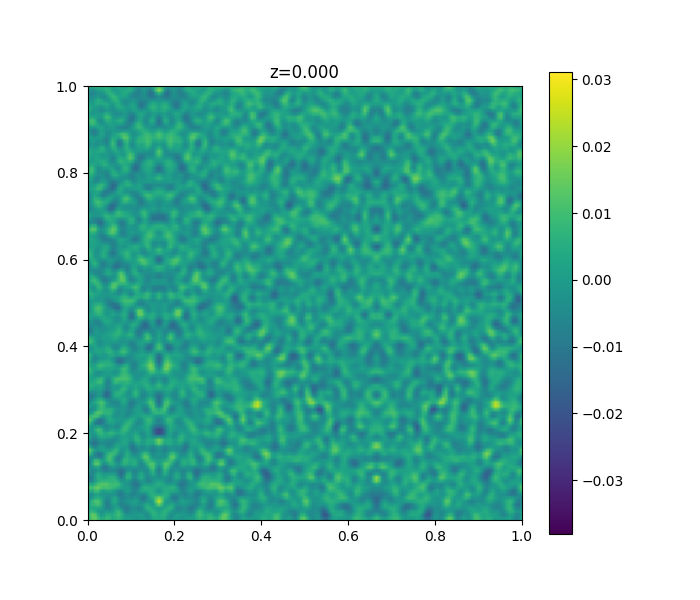

In [ ]:
from plotting3d import slice_3d
%matplotlib widget
_ = slice_3d(diffmaps["kweighted"].to_3d_numpy_map(map_sampling=map_sampling))
